In [5]:
import os
import random
import shutil
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Updated for your Mac's Downloads folder
source_dir = Path("/Users/mevinimunaweera/Downloads/FoodFreshnessDataset/Dataset")

# Creates the sample folder directly inside your current VS Code project directory
destination_dir = Path("./FoodFreshnessSample")
destination_dir.mkdir(parents=True, exist_ok=True)

# Allowed image extensions
allowed_ext = [".jpg", ".jpeg", ".png"]

# Loop through Fresh and Rotten folders
for freshness_type in ["Fresh", "Rotten"]:
    freshness_path = source_dir / freshness_type

    if not freshness_path.exists():
        print(
            f"⚠️ Warning: Could not find folder {freshness_path}. Please check your dataset path structure."
        )
        continue

    for category_folder in freshness_path.iterdir():
        if category_folder.is_dir():
            # Filter only image files with allowed extensions
            images = [
                img
                for img in category_folder.iterdir()
                if img.suffix.lower() in allowed_ext
            ]

            # Perfectly indented and lowered to 20 images to prevent kernel crash
            selected_images = (
                random.sample(images, 20) if len(images) >= 20 else images
            )

            # Destination subfolder path
            dest_subfolder = destination_dir / freshness_type / category_folder.name
            dest_subfolder.mkdir(parents=True, exist_ok=True)

            # Copy files
            for img_path in selected_images:
                shutil.copy(img_path, dest_subfolder)

print("✅ Randomly selected and copied up to 20 images from each folder!")


✅ Randomly selected and copied up to 20 images from each folder!


In [6]:
import os
from pathlib import Path
import pandas as pd

# 1. FIXED: Points to the local sample directory created by your first cell
dataset_path = "./FoodFreshnessSample"

# Define valid image extensions
valid_extensions = (".jpg", ".jpeg", ".png")

# List to store the data
data = []

# Loop through 'Fresh' and 'Rotten'
for freshness_type in ["Fresh", "Rotten"]:
    freshness_dir = os.path.join(dataset_path, freshness_type)

    # Prevent crash if directory doesn't exist
    if not os.path.exists(freshness_dir):
        continue

    # Go through each category folder
    for category in os.listdir(freshness_dir):
        category_path = os.path.join(freshness_dir, category)

        if os.path.isdir(category_path):
            image_files = [
                f
                for f in os.listdir(category_path)
                if f.lower().endswith(valid_extensions)
            ]
            count = len(image_files)

            # Append to data list
            data.append(
                {
                    "Category": category,
                    "Freshness": freshness_type,
                    "Folder Path": f"{freshness_type}/{category}",
                    "Image Count": count,
                }
            )

# Convert to DataFrame
df = pd.DataFrame(data)

# 2. FIXED: Saves the CSV directly into your current VS Code project directory
csv_path = "./file_counts.csv"
df.to_csv(csv_path, index=False)

print(f"✅ File counts saved to local workspace: {csv_path}")


✅ File counts saved to local workspace: ./file_counts.csv


In [7]:
import os
from pathlib import Path

# FIXED: Points to your local sample folder instead of Kaggle
base_dir = Path("./FoodFreshnessSample")

# Loop through Fresh and Rotten
for freshness_type in ["Fresh", "Rotten"]:
    freshness_path = base_dir / freshness_type

    # Prevent crash if directory doesn't exist
    if not freshness_path.exists():
        continue

    for category_folder in freshness_path.iterdir():
        if category_folder.is_dir():
            folder_name = category_folder.name
            files = sorted([f for f in category_folder.iterdir() if f.is_file()])

            for idx, file_path in enumerate(files, start=1):
                # Keep original file extension
                extension = file_path.suffix
                new_name = f"{folder_name}_{idx}{extension}"
                new_path = category_folder / new_name

                # Rename the file
                file_path.rename(new_path)

print("✅ All files renamed successfully with folder name and index!")


✅ All files renamed successfully with folder name and index!


In [8]:
import os
import cv2
import numpy as np
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tqdm import tqdm

# FIXED: Points to your local sample folder instead of Kaggle
dataset_path = "./FoodFreshnessSample"

# Image size
img_size = (128, 128)

# Store data and labels
X = []
y = []

# Loop through Fresh and Rotten
for freshness_type in ["Fresh", "Rotten"]:
    freshness_dir = os.path.join(dataset_path, freshness_type)

    # Prevent crash if directory doesn't exist
    if not os.path.exists(freshness_dir):
        continue

    for folder in os.listdir(freshness_dir):
        folder_path = os.path.join(freshness_dir, folder)

        if os.path.isdir(folder_path):
            for filename in tqdm(
                os.listdir(folder_path), desc=f"Processing {folder}"
            ):
                file_path = os.path.join(folder_path, filename)
                try:
                    # Read image
                    img = cv2.imread(file_path)

                    # Ensure the image was loaded correctly before filtering
                    if img is None:
                        continue

                    # Noise Reduction (Gaussian Blur)
                    blurred = cv2.GaussianBlur(img, (5, 5), 0)

                    # Convert to Grayscale
                    gray = cv2.cvtColor(blurred, cv2.COLOR_BGR2GRAY)

                    # Resize
                    resized = cv2.resize(gray, img_size)

                    # Edge Detection (Canny)
                    edges = cv2.Canny(resized, 100, 200)

                    # Normalize
                    normalized = edges / 255.0

                    # Reshape to (128, 128, 1)
                    normalized = np.expand_dims(normalized, axis=-1)

                    # Append data and label
                    X.append(normalized)
                    y.append(folder)
                except Exception as e:
                    print(f"❌ Error processing {file_path}: {e}")

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

print(f"✅ Dataset shape: {X.shape}")
print(f"✅ Labels shape: {y_categorical.shape}")

# Add MaxPooling2D layer for demonstration
example_input = tf.keras.Input(shape=(128, 128, 1))
pooled_output = MaxPooling2D(pool_size=(2, 2))(example_input)

print("✅ MaxPooling2D layer added (will be used in model).")


Processing RottenPotato: 100%|██████████| 90/90 [00:00<00:00, 901.70it/s]


✅ Dataset shape: (1846, 128, 128, 1)
✅ Labels shape: (1846, 26)
✅ MaxPooling2D layer added (will be used in model).


In [9]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# FIXED FOR LOCAL VS CODE
source_path = "./FoodFreshnessSample"
augmented_path = "./augmented_dataset"

# Create destination folders
os.makedirs(augmented_path, exist_ok=True)

# Image size
img_size = (128, 128)


# Augmentation functions
def rotate_image(img, angle):
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    rot_mat = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(img, rot_mat, (w, h))


def adjust_brightness(img, value=30):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    # Use standard uint32 arithmetic or cast to prevent array wrapping on addition
    hsv_channels = list(cv2.split(hsv))
    hsv_channels[2] = np.clip(hsv_channels[2].astype(np.int16) + value, 0, 255).astype(
        np.uint8
    )
    hsv = cv2.merge(hsv_channels)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)


# Loop through each class folder
for freshness_type in ["Fresh", "Rotten"]:
    freshness_dir = os.path.join(source_path, freshness_type)

    if not os.path.exists(freshness_dir):
        continue

    for folder in os.listdir(freshness_dir):
        folder_path = os.path.join(freshness_dir, folder)
        target_folder = os.path.join(augmented_path, freshness_type, folder)

        if os.path.isdir(folder_path):
            os.makedirs(target_folder, exist_ok=True)

            for idx, filename in enumerate(
                tqdm(os.listdir(folder_path), desc=f"Augmenting {folder}")
            ):
                file_path = os.path.join(folder_path, filename)
                img = cv2.imread(file_path)

                if img is None:
                    continue

                # Resize
                img = cv2.resize(img, img_size)

                # 1. Original
                cv2.imwrite(
                    os.path.join(target_folder, f"{folder}_{idx}_original.jpg"),
                    img,
                )

                # 2. Horizontal Flip
                flipped = cv2.flip(img, 1)
                cv2.imwrite(
                    os.path.join(target_folder, f"{folder}_{idx}_flipped.jpg"),
                    flipped,
                )

                # 3. Random Rotation (20°)
                rotated = rotate_image(img, angle=20)
                cv2.imwrite(
                    os.path.join(target_folder, f"{folder}_{idx}_rotated.jpg"),
                    rotated,
                )

                # 4. Brightness Increase
                brighter = adjust_brightness(img, value=40)
                cv2.imwrite(
                    os.path.join(target_folder, f"{folder}_{idx}_bright.jpg"),
                    brighter,
                )

                # 5. 180° Rotation
                rotated_180 = rotate_image(img, angle=180)
                cv2.imwrite(
                    os.path.join(
                        target_folder, f"{folder}_{idx}_rotated180.jpg"
                    ),
                    rotated_180,
                )

print("✅ Data augmentation complete! Checked inside './augmented_dataset'")


Augmenting RottenPotato: 100%|██████████| 90/90 [00:00<00:00, 731.04it/s]

✅ Data augmentation complete! Checked inside './augmented_dataset'


In [10]:
import os
import pandas as pd

# FIXED: Points to your local augmented folder instead of Kaggle
dataset_path = "./augmented_dataset"

# Define valid image extensions
valid_extensions = (".jpg", ".jpeg", ".png")

# List to store the data
data = []

# Loop through 'Fresh' and 'Rotten'
for freshness_type in ["Fresh", "Rotten"]:
    freshness_dir = os.path.join(dataset_path, freshness_type)

    # Prevent crash if directory doesn't exist
    if not os.path.exists(freshness_dir):
        continue

    # Go through each category folder
    for category in os.listdir(freshness_dir):
        category_path = os.path.join(freshness_dir, category)

        if os.path.isdir(category_path):
            image_files = [
                f
                for f in os.listdir(category_path)
                if f.lower().endswith(valid_extensions)
            ]
            count = len(image_files)

            # Append to data list
            data.append(
                {
                    "Category": category,
                    "Freshness": freshness_type,
                    "Folder Path": f"{freshness_type}/{category}",
                    "Image Count": count,
                }
            )

# Convert to DataFrame
df = pd.DataFrame(data)

# FIXED: Saves the CSV directly into your current local directory
csv_path = "./file_counts_augmented.csv"
df.to_csv(csv_path, index=False)

print(f"✅ Augmented file counts saved to local workspace: {csv_path}")


✅ Augmented file counts saved to local workspace: ./file_counts_augmented.csv


In [11]:
import os
import shutil

# === FIXED: Points to your local sample folder instead of Kaggle ===
FRESH_ROOT = "./FoodFreshnessSample/Fresh"
ROTTEN_ROOT = "./FoodFreshnessSample/Rotten"

# === FIXED: Points to your local workspace clustering folder ===
FRESH_TARGET = "./Clustering/Fresh"
ROTTEN_TARGET = "./Clustering/Rotten"

# === Create Target Folders if They Don't Exist ===
os.makedirs(FRESH_TARGET, exist_ok=True)
os.makedirs(ROTTEN_TARGET, exist_ok=True)


# === Helper Function to Collect and Move Images ===
def collect_images(source_root, target_folder):
    if not os.path.exists(source_root):
        print(f"⚠️ Warning: Source folder {source_root} does not exist.")
        return

    count = 0
    for root, _, files in os.walk(source_root):
        for file in files:
            if file.lower().endswith((".jpg", ".png", ".jpeg")):
                source_path = os.path.join(root, file)
                dest_path = os.path.join(target_folder, f"{count}_{file}")
                shutil.copy2(source_path, dest_path)
                count += 1
    print(f"Copied {count} images to {target_folder}")


# === Run Collection ===
collect_images(FRESH_ROOT, FRESH_TARGET)
collect_images(ROTTEN_ROOT, ROTTEN_TARGET)


Copied 969 images to ./Clustering/Fresh
Copied 877 images to ./Clustering/Rotten


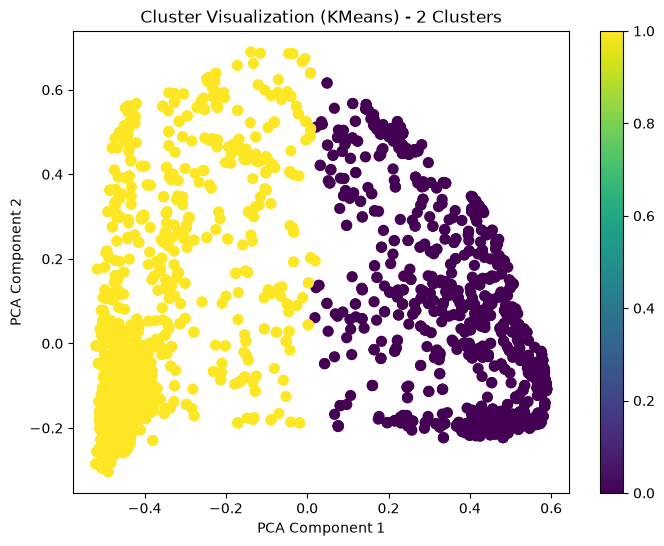

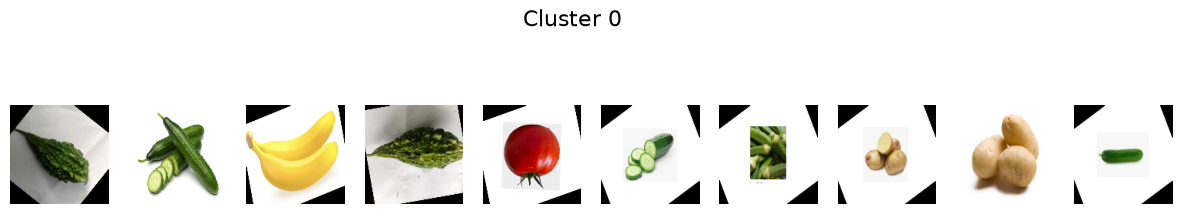

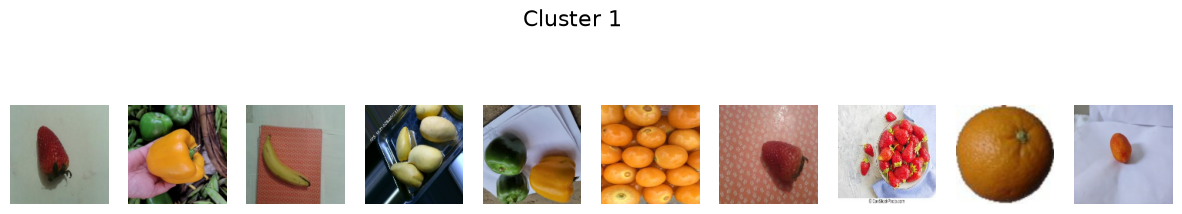

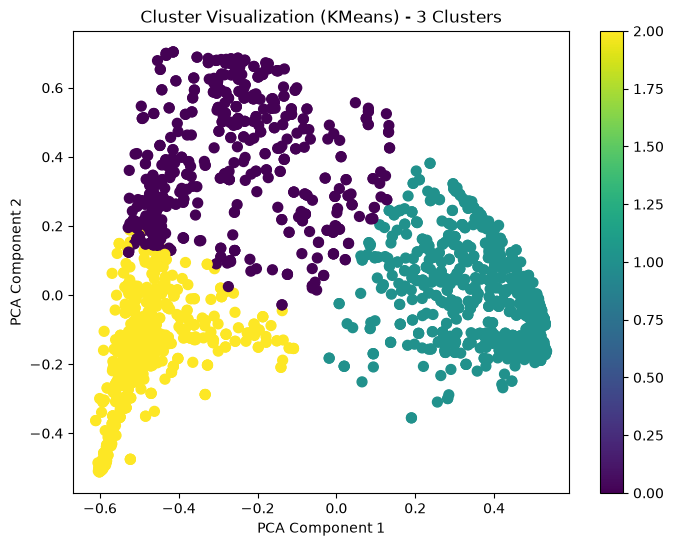

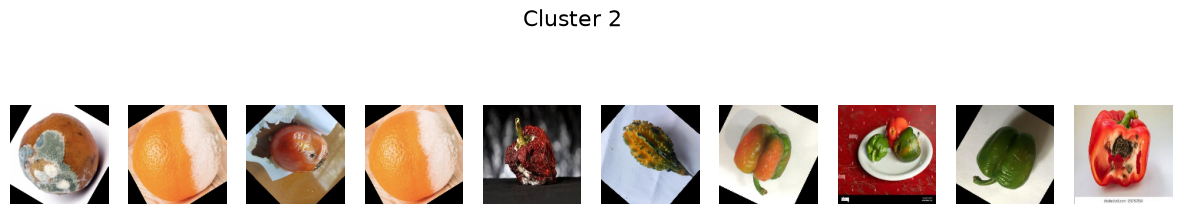

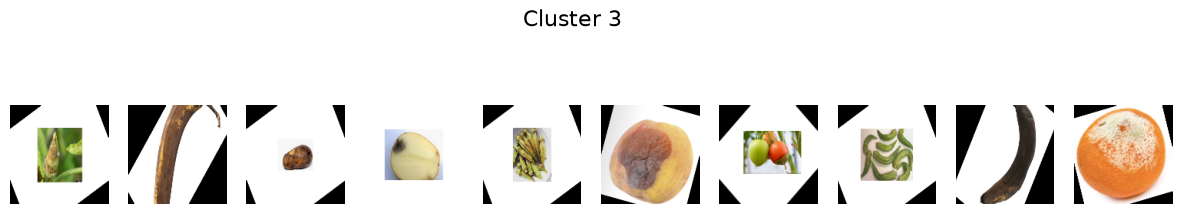

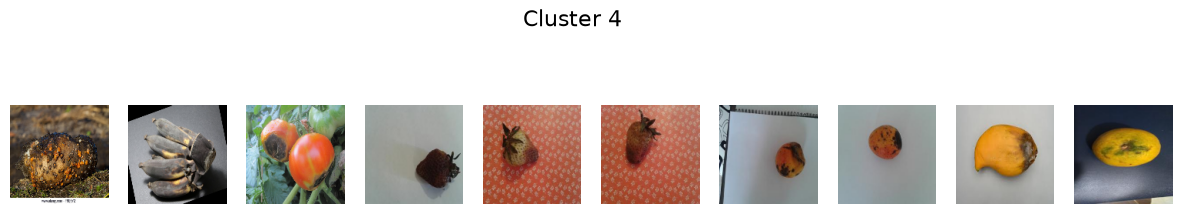

In [12]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# === FIXED: LOCAL SETTINGS ===
FRESH_DIR = "./Clustering/Fresh"
ROTTEN_DIR = "./Clustering/Rotten"
OUTPUT_DIR = "./kmeans_clustered_images"
NUM_FRESH_CLUSTERS = 2
NUM_ROTTEN_CLUSTERS = 3
SAMPLES_PER_CLUSTER = 10

# === CREATE OUTPUT FOLDER ===
os.makedirs(OUTPUT_DIR, exist_ok=True)


# === FEATURE EXTRACTION ===
def extract_color_histogram(image, bins=(8, 8, 8)):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist(
        [hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256]
    )
    cv2.normalize(hist, hist)
    return hist.flatten()


# === LOAD IMAGES & FEATURES ===
def load_images_and_features(folder):
    images = []
    features = []
    filenames = []

    if not os.path.exists(folder):
        print(f"⚠️ Warning: Folder {folder} does not exist.")
        return np.array([]), np.array([]), []

    for file in os.listdir(folder):
        if file.lower().endswith((".jpg", ".png", ".jpeg")):
            path = os.path.join(folder, file)
            img = cv2.imread(path)
            if img is not None:
                img_resized = cv2.resize(img, (128, 128))
                feat = extract_color_histogram(img_resized)
                features.append(feat)
                images.append(img_resized)
                filenames.append(file)
    return np.array(images), np.array(features), filenames


# === CLUSTERING FUNCTION ===
def cluster_and_visualize(
    images, features, filenames, n_clusters, cluster_offset
):
    if len(features) == 0:
        print("⚠️ No data available to cluster.")
        return

    # FIXED: Added 'n_init="auto"' explicitly to prevent scikit-learn warnings in your console
    kmeans = KMeans(n_clusters=n_clusters, n_init="auto", random_state=42)
    labels = kmeans.fit_predict(features)

    # PCA Visualization
    pca = PCA(n_components=2)
    features_pca = pca.fit_transform(features)

    plt.figure(figsize=(8, 6))
    plt.scatter(
        features_pca[:, 0],
        features_pca[:, 1],
        c=labels,
        cmap="viridis",
        s=50,
    )
    plt.title(f"Cluster Visualization (KMeans) - {n_clusters} Clusters")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.colorbar()
    plt.show()

    # Cluster images and save them
    for cluster_id in range(n_clusters):
        cluster_index = cluster_id + cluster_offset
        cluster_dir = os.path.join(OUTPUT_DIR, f"cluster_{cluster_index}")
        os.makedirs(cluster_dir, exist_ok=True)

        cluster_images = images[labels == cluster_id]
        cluster_files = np.array(filenames)[labels == cluster_id]

        # Save images
        for img, fname in zip(cluster_images, cluster_files):
            save_path = os.path.join(cluster_dir, fname)
            cv2.imwrite(save_path, img)

        # Plot the images of the cluster
        num_samples = min(SAMPLES_PER_CLUSTER, len(cluster_images))

        # FIXED: Added fallback logic if a cluster contains zero or one image to avoid subplots breaking
        if num_samples > 0:
            fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
            fig.suptitle(f"Cluster {cluster_index}", fontsize=16)

            if num_samples == 1:
                axes.imshow(cv2.cvtColor(cluster_images[0], cv2.COLOR_BGR2RGB))
                axes.axis("off")
            else:
                for i, ax in enumerate(axes):
                    if i < len(cluster_images):
                        ax.imshow(
                            cv2.cvtColor(cluster_images[i], cv2.COLOR_BGR2RGB)
                        )
                        ax.axis("off")
            plt.show()


# === RUNNING PIPELINE ===

# Fresh images
fresh_images, fresh_features, fresh_filenames = load_images_and_features(
    FRESH_DIR
)
cluster_and_visualize(
    fresh_images,
    fresh_features,
    fresh_filenames,
    NUM_FRESH_CLUSTERS,
    cluster_offset=0,
)

# Rotten images
rotten_images, rotten_features, rotten_filenames = load_images_and_features(
    ROTTEN_DIR
)
cluster_and_visualize(
    rotten_images,
    rotten_features,
    rotten_filenames,
    NUM_ROTTEN_CLUSTERS,
    cluster_offset=NUM_FRESH_CLUSTERS,
)


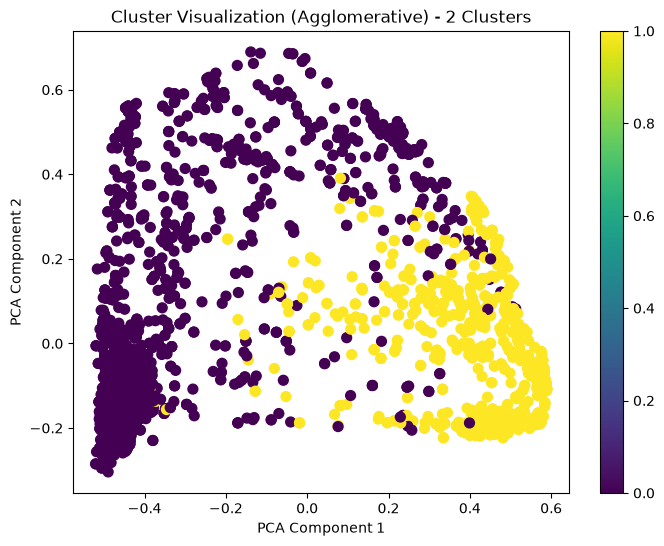

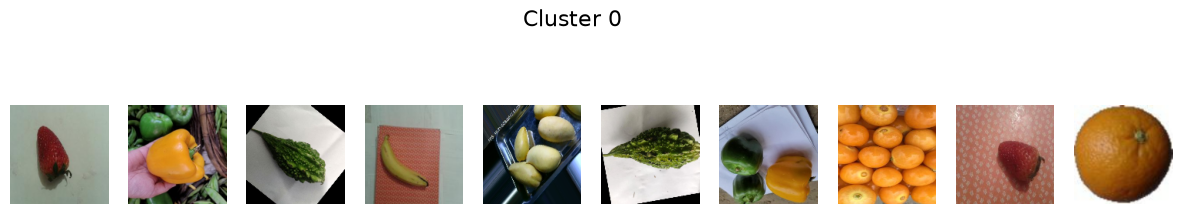

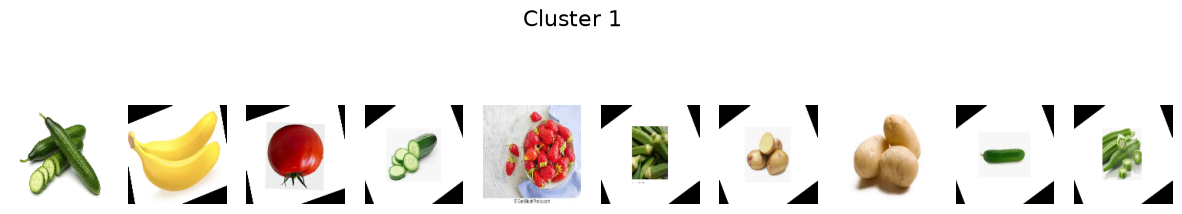

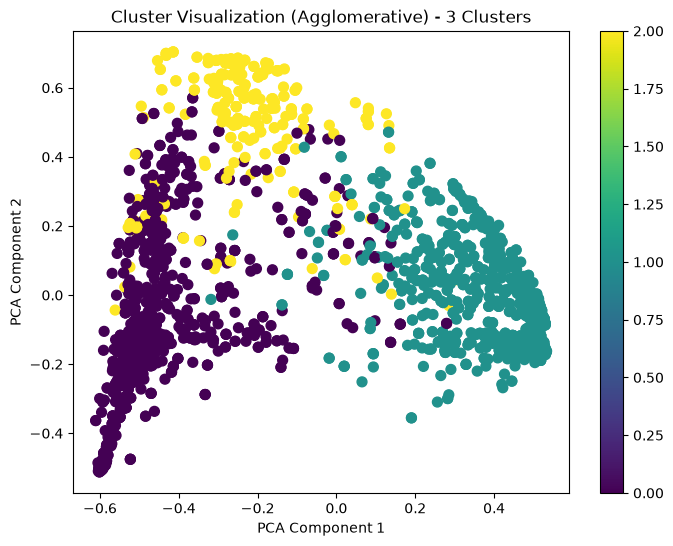

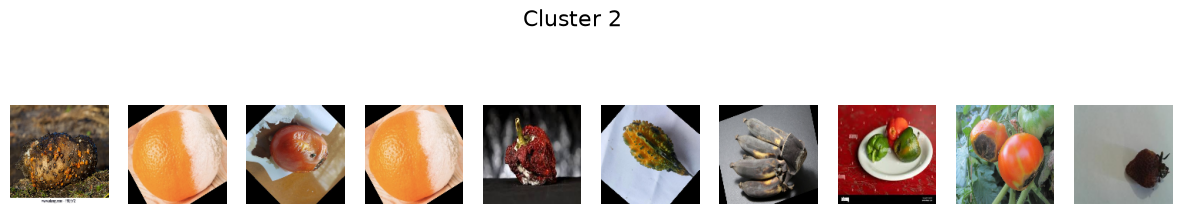

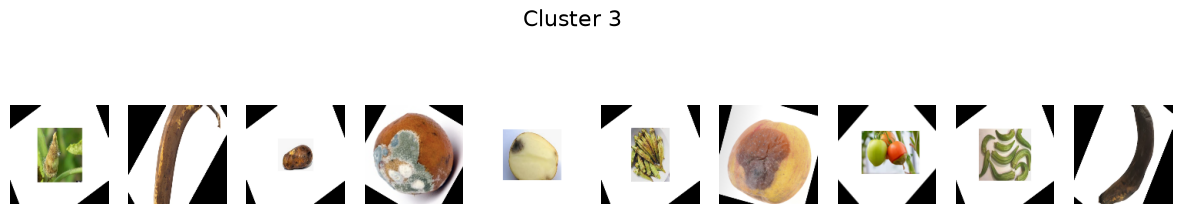

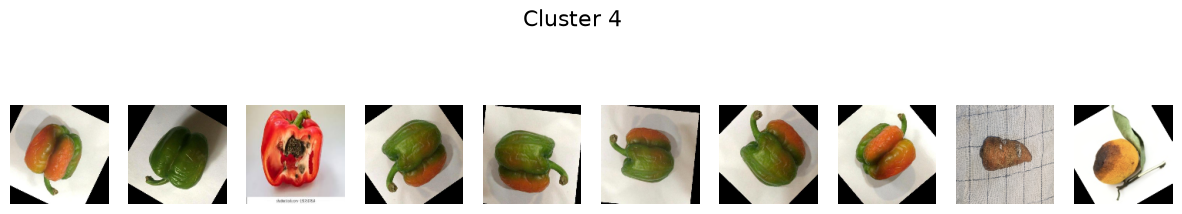

In [13]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

# === FIXED: LOCAL SETTINGS ===
FRESH_DIR = "./Clustering/Fresh"
ROTTEN_DIR = "./Clustering/Rotten"
OUTPUT_DIR = "./agglomerative_clustered_images"
NUM_FRESH_CLUSTERS = 2
NUM_ROTTEN_CLUSTERS = 3
SAMPLES_PER_CLUSTER = 10

# === CREATE OUTPUT FOLDER ===
os.makedirs(OUTPUT_DIR, exist_ok=True)


# === FEATURE EXTRACTION ===
def extract_color_histogram(image, bins=(8, 8, 8)):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist)
    return hist.flatten()


# === LOAD IMAGES & FEATURES ===
def load_images_and_features(folder):
    images = []
    features = []
    filenames = []

    if not os.path.exists(folder):
        print(f"⚠️ Warning: Folder {folder} does not exist.")
        return np.array([]), np.array([]), []

    for file in os.listdir(folder):
        if file.lower().endswith((".jpg", ".png", ".jpeg")):
            path = os.path.join(folder, file)
            img = cv2.imread(path)
            if img is not None:
                img_resized = cv2.resize(img, (128, 128))
                feat = extract_color_histogram(img_resized)
                features.append(feat)
                images.append(img_resized)
                filenames.append(file)
    return np.array(images), np.array(features), filenames


# === AGGLOMERATIVE CLUSTERING FUNCTION ===
def cluster_and_visualize(
    images, features, filenames, n_clusters, cluster_offset
):
    if len(features) == 0:
        print("⚠️ No data available to cluster.")
        return

    # Agglomerative Clustering
    agglomerative = AgglomerativeClustering(n_clusters=n_clusters)
    labels = agglomerative.fit_predict(features)

    # PCA Visualization
    pca = PCA(n_components=2)
    features_pca = pca.fit_transform(features)

    plt.figure(figsize=(8, 6))
    plt.scatter(
        features_pca[:, 0],
        features_pca[:, 1],
        c=labels,
        cmap="viridis",
        s=50,
    )
    plt.title(f"Cluster Visualization (Agglomerative) - {n_clusters} Clusters")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.colorbar()
    plt.show()

    # Cluster images and save them
    for cluster_id in range(n_clusters):
        cluster_index = cluster_id + cluster_offset
        cluster_dir = os.path.join(OUTPUT_DIR, f"cluster_{cluster_index}")
        os.makedirs(cluster_dir, exist_ok=True)

        cluster_images = images[labels == cluster_id]
        cluster_files = np.array(filenames)[labels == cluster_id]

        # Save images
        for img, fname in zip(cluster_images, cluster_files):
            save_path = os.path.join(cluster_dir, fname)
            cv2.imwrite(save_path, img)

        # Plot the images of the cluster
        num_samples = min(SAMPLES_PER_CLUSTER, len(cluster_images))

        # FIXED: Added safety logic for subplots handling small cluster sizes
        if num_samples > 0:
            fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
            fig.suptitle(f"Cluster {cluster_index}", fontsize=16)

            if num_samples == 1:
                axes.imshow(cv2.cvtColor(cluster_images[0], cv2.COLOR_BGR2RGB))
                axes.axis("off")
            else:
                for i, ax in enumerate(axes):
                    if i < len(cluster_images):
                        ax.imshow(
                            cv2.cvtColor(cluster_images[i], cv2.COLOR_BGR2RGB)
                        )
                        ax.axis("off")
            plt.show()


# === RUNNING PIPELINE ===

# Fresh images
fresh_images, fresh_features, fresh_filenames = load_images_and_features(
    FRESH_DIR
)
cluster_and_visualize(
    fresh_images,
    fresh_features,
    fresh_filenames,
    NUM_FRESH_CLUSTERS,
    cluster_offset=0,
)

# Rotten images
rotten_images, rotten_features, rotten_filenames = load_images_and_features(
    ROTTEN_DIR
)
cluster_and_visualize(
    rotten_images,
    rotten_features,
    rotten_filenames,
    NUM_ROTTEN_CLUSTERS,
    cluster_offset=NUM_FRESH_CLUSTERS,
)


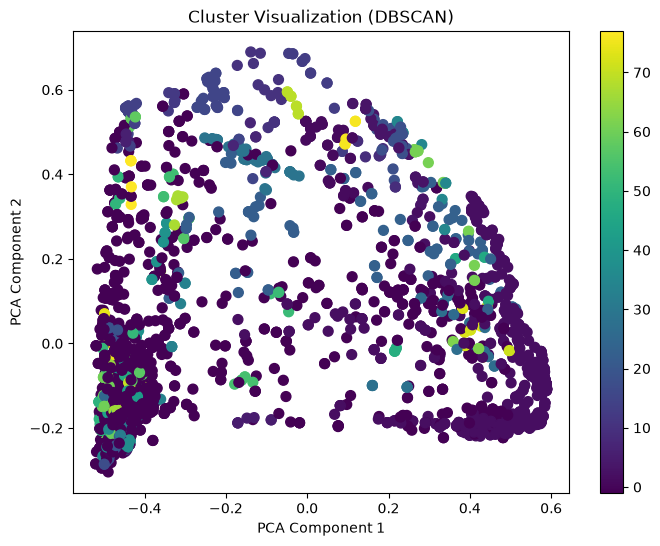

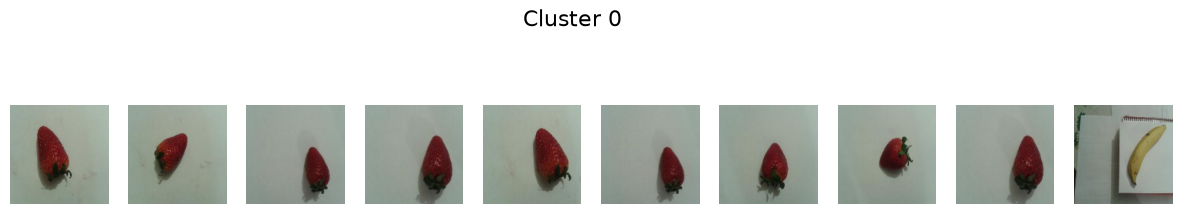

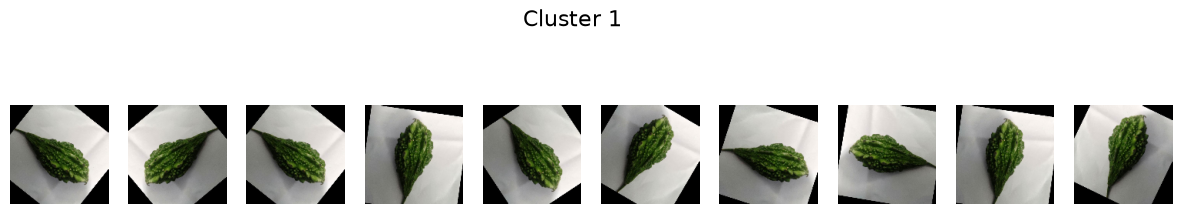

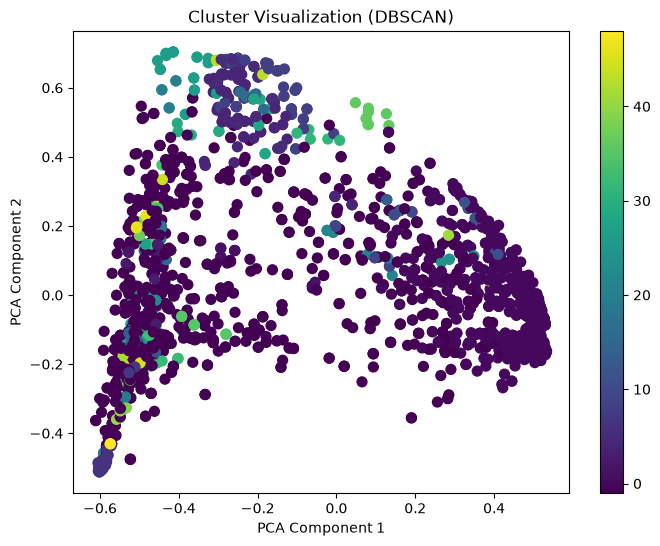

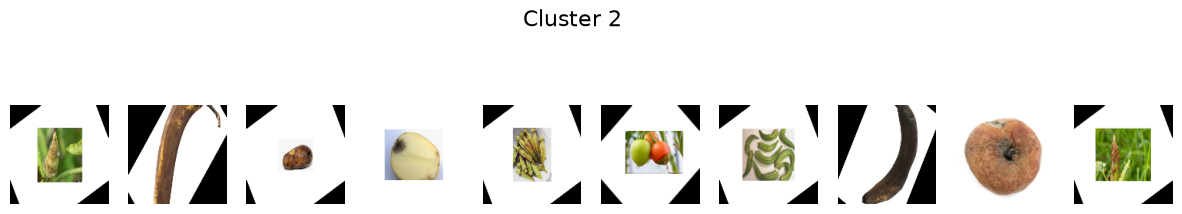

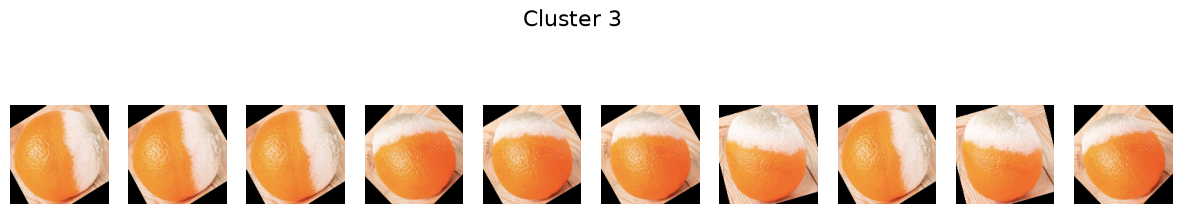

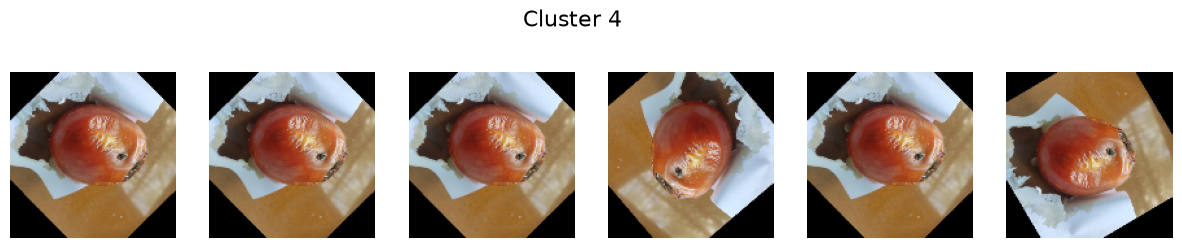

In [14]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# === FIXED: LOCAL SETTINGS ===
FRESH_DIR = "./Clustering/Fresh"
ROTTEN_DIR = "./Clustering/Rotten"
OUTPUT_DIR = "./dbscan_clustered_images"
EPSILON = 0.3  # Maximum distance between two samples for one to be considered as in the neighborhood of the other
MIN_SAMPLES = 5  # The number of samples in a neighborhood for a point to be considered as a core point
SAMPLES_PER_CLUSTER = 10

# === CREATE OUTPUT FOLDER ===
os.makedirs(OUTPUT_DIR, exist_ok=True)


# === FEATURE EXTRACTION ===
def extract_color_histogram(image, bins=(8, 8, 8)):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist)
    return hist.flatten()


# === LOAD IMAGES & FEATURES ===
def load_images_and_features(folder):
    images = []
    features = []
    filenames = []

    if not os.path.exists(folder):
        print(f"⚠️ Warning: Folder {folder} does not exist.")
        return np.array([]), np.array([]), []

    for file in os.listdir(folder):
        if file.lower().endswith((".jpg", ".png", ".jpeg")):
            path = os.path.join(folder, file)
            img = cv2.imread(path)
            if img is not None:
                img_resized = cv2.resize(img, (128, 128))
                feat = extract_color_histogram(img_resized)
                features.append(feat)
                images.append(img_resized)
                filenames.append(file)  # save file name only
    return np.array(images), np.array(features), filenames


# === DBSCAN CLUSTERING FUNCTION ===
def cluster_and_visualize(
    images, features, filenames, cluster_offset, n_clusters
):
    if len(features) == 0:
        print("⚠️ No data available to cluster.")
        return

    # DBSCAN Clustering
    dbscan = DBSCAN(eps=EPSILON, min_samples=MIN_SAMPLES)
    labels = dbscan.fit_predict(features)

    # PCA Visualization
    pca = PCA(n_components=2)
    features_pca = pca.fit_transform(features)

    plt.figure(figsize=(8, 6))
    plt.scatter(
        features_pca[:, 0],
        features_pca[:, 1],
        c=labels,
        cmap="viridis",
        s=50,
    )
    plt.title(f"Cluster Visualization (DBSCAN)")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.colorbar()
    plt.show()

    # Cluster images and save them
    unique_labels = set(labels)
    cluster_count = 0  # Counter for cluster index
    for cluster_id in unique_labels:
        if cluster_id == -1:  # Points labeled as -1 are considered noise
            continue
        cluster_count += 1
        if cluster_count > n_clusters:  # Limit the number of clusters
            break

        cluster_index = cluster_id + cluster_offset
        cluster_dir = os.path.join(OUTPUT_DIR, f"cluster_{cluster_index}")
        os.makedirs(cluster_dir, exist_ok=True)

        cluster_images = images[labels == cluster_id]
        cluster_files = np.array(filenames)[labels == cluster_id]

        # Save images
        for img, fname in zip(cluster_images, cluster_files):
            save_path = os.path.join(cluster_dir, fname)
            cv2.imwrite(save_path, img)

        # Plot the images of the cluster
        num_samples = min(SAMPLES_PER_CLUSTER, len(cluster_images))

        # FIXED: Added fallback logic if a cluster contains zero or one image to avoid subplots breaking
        if num_samples > 0:
            fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
            fig.suptitle(f"Cluster {cluster_index}", fontsize=16)

            if num_samples == 1:
                axes.imshow(cv2.cvtColor(cluster_images[0], cv2.COLOR_BGR2RGB))
                axes.axis("off")
            else:
                for i, ax in enumerate(axes):
                    if i < len(cluster_images):
                        ax.imshow(
                            cv2.cvtColor(cluster_images[i], cv2.COLOR_BGR2RGB)
                        )
                        ax.axis("off")
            plt.show()


# === RUNNING PIPELINE ===

# Fresh images - clustering into 2 clusters
fresh_images, fresh_features, fresh_filenames = load_images_and_features(
    FRESH_DIR
)
cluster_and_visualize(
    fresh_images,
    fresh_features,
    fresh_filenames,
    cluster_offset=0,
    n_clusters=2,
)

# Rotten images - clustering into 3 clusters
rotten_images, rotten_features, rotten_filenames = load_images_and_features(
    ROTTEN_DIR
)
cluster_and_visualize(
    rotten_images,
    rotten_features,
    rotten_filenames,
    cluster_offset=2,
    n_clusters=3,
)


In [15]:
import os
import shutil
from sklearn.model_selection import train_test_split

# === FIXED: LOCAL SETTINGS ===
dataset_dir = "./kmeans_clustered_images"
train_dir = "./K Means Model Data/train"
val_dir = "./K Means Model Data/val"
test_dir = "./K Means Model Data/test"

# Class names mapped from clusters
cluster_to_class = {
    "cluster_0": "Fresh",
    "cluster_1": "Slightly_Aged",
    "cluster_2": "Stale",
    "cluster_3": "Spoiled",
    "cluster_4": "Rotten",
}

# Create directories for train, validation, and test splits
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Create subdirectories for each class
for cluster_name in cluster_to_class.values():
    os.makedirs(os.path.join(train_dir, cluster_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cluster_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cluster_name), exist_ok=True)

# Move files to respective directories based on cluster
if os.path.exists(dataset_dir):
    for cluster_folder in os.listdir(dataset_dir):
        cluster_path = os.path.join(dataset_dir, cluster_folder)

        if cluster_folder in cluster_to_class and os.path.isdir(cluster_path):
            # Get the new class name
            new_class = cluster_to_class[cluster_folder]

            # Filter out hidden files like .DS_Store to avoid crash
            images = [
                f
                for f in os.listdir(cluster_path)
                if f.lower().endswith((".jpg", ".png", ".jpeg"))
            ]

            # FIXED: Added protection in case a cluster has 0 or 1 image from the earlier lowered sample limits
            if len(images) < 3:
                print(
                    f"⚠️ Skipping split for {cluster_folder}: Too few images ({len(images)})."
                )
                # Fallback: Put everything into training if there aren't enough images to split
                for image in images:
                    shutil.copy(
                        os.path.join(cluster_path, image),
                        os.path.join(train_dir, new_class, image),
                    )
                continue

            # Split data into training, validation, and test
            train_images, test_images = train_test_split(
                images, test_size=0.2, random_state=42
            )
            val_images, test_images = train_test_split(
                test_images, test_size=0.5, random_state=42
            )

            # FIXED: Changed shutil.move to shutil.copy to keep clustered originals intact for debugging
            for image in train_images:
                shutil.copy(
                    os.path.join(cluster_path, image),
                    os.path.join(train_dir, new_class, image),
                )

            for image in val_images:
                shutil.copy(
                    os.path.join(cluster_path, image),
                    os.path.join(val_dir, new_class, image),
                )

            for image in test_images:
                shutil.copy(
                    os.path.join(cluster_path, image),
                    os.path.join(test_dir, new_class, image),
                )
else:
    print(f"⚠️ Warning: Dataset directory {dataset_dir} not found.")

print("✅ Data successfully split into train, validation, and test sets!")


✅ Data successfully split into train, validation, and test sets!


In [16]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# FIXED: Re-declare local paths explicitly in this cell to prevent variable reference errors if cells are run out of order
train_dir = "./K Means Model Data/train"
val_dir = "./K Means Model Data/val"
test_dir = "./K Means Model Data/test"


# Function to double check subfolders and filter empty directories
def print_class_counts(directory_path, name):
    if not os.path.exists(directory_path):
        print(f"⚠️ Warning: {name} directory does not exist yet.")
        return
    classes = [
        d
        for d in os.listdir(directory_path)
        if os.path.isdir(os.path.join(directory_path, d))
    ]
    print(f"\n📂 Checking {name} structure:")
    for cls in classes:
        count = len(os.listdir(os.path.join(directory_path, cls)))
        print(f"  - {cls}: {count} images")


print_class_counts(train_dir, "Training Set")

# ImageDataGenerator setup for training and validation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255, horizontal_flip=True, zoom_range=0.2
)
val_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

# Flow from directory for training, validation, and test sets
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(128, 128), batch_size=32, class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False,
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False,
)

print("\n✅ Data loaded successfully into Keras generators!")



📂 Checking Training Set structure:
  - Stale: 1572 images
  - Fresh: 2563 images
  - Spoiled: 1839 images
  - Rotten: 1184 images
  - Slightly_Aged: 2607 images
Found 9765 images belonging to 5 classes.
Found 1885 images belonging to 5 classes.
Found 1877 images belonging to 5 classes.

✅ Data loaded successfully into Keras generators!



🚀 Training MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/2
306/306 ━━━━━━━━━━━━━━━━━━━━ 24s 70ms/step - accuracy: 0.2811 - loss: 1.9063 - val_accuracy: 0.3671 - val_loss: 1.3701
Epoch 2/2
306/306 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.3394 - loss: 1.5010 - val_accuracy: 0.3809 - val_loss: 1.3124


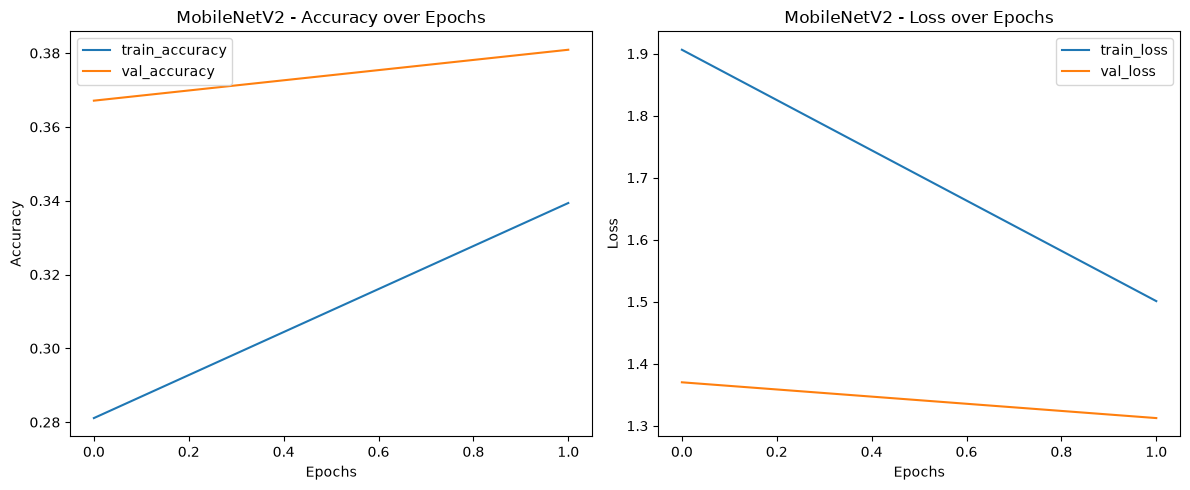

59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step


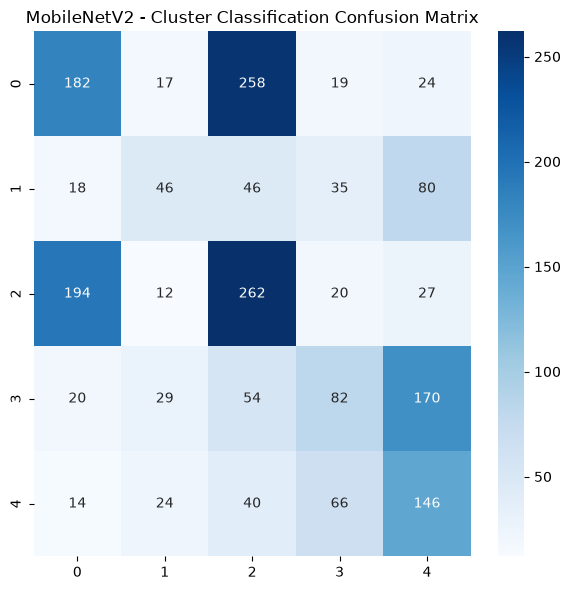

✅ MobileNetV2 - Training complete, confusion matrix and classification report saved.

🚀 Training VGG16...
Epoch 1/2
306/306 ━━━━━━━━━━━━━━━━━━━━ 234s 764ms/step - accuracy: 0.2482 - loss: 1.7294 - val_accuracy: 0.2881 - val_loss: 1.5881
Epoch 2/2
306/306 ━━━━━━━━━━━━━━━━━━━━ 250s 818ms/step - accuracy: 0.2602 - loss: 1.6244 - val_accuracy: 0.3194 - val_loss: 1.5394


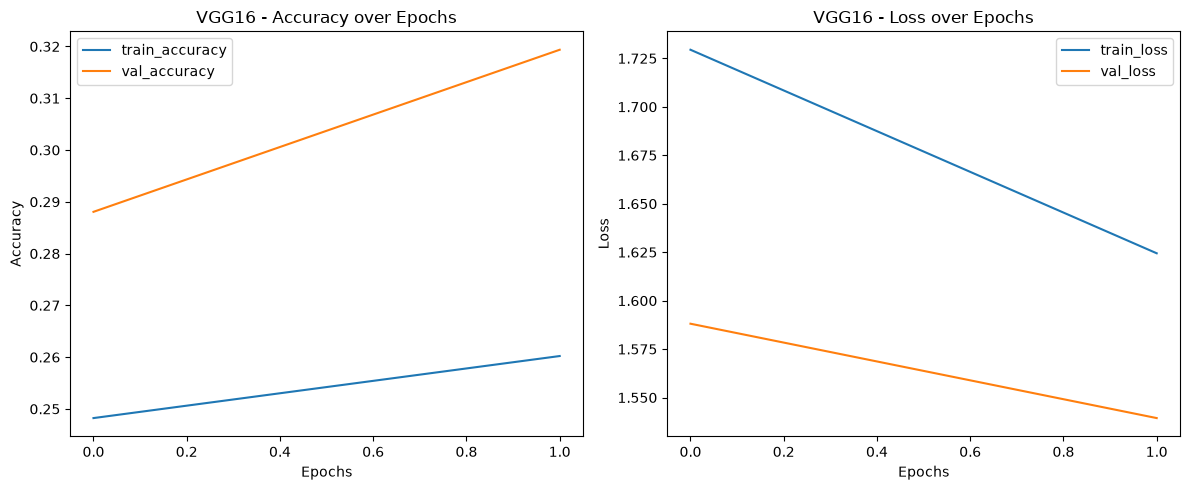

59/59 ━━━━━━━━━━━━━━━━━━━━ 38s 644ms/step


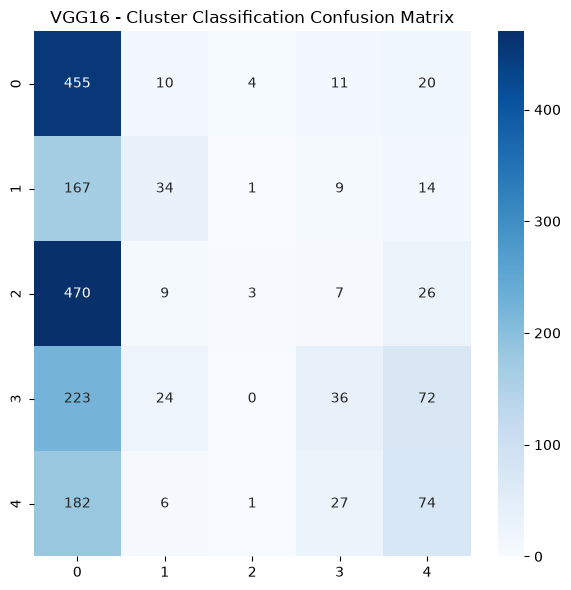

✅ VGG16 - Training complete, confusion matrix and classification report saved.
✅ All models trained, evaluated, and saved successfully!


In [18]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.applications import (
    VGG16,
    VGG19,
    DenseNet121,
    InceptionV3,
    MobileNetV2,
    ResNet50,
    Xception,
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import (
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    GlobalAveragePooling2D,
    MaxPooling2D,
)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam

# === FIXED: DEPLOYMENT SETTINGS FOR LOCAL SYSTEM ===
EPOCHS = 2  # Drops training rounds from 10 to 2 for quick validation
NUM_CLASSES = 5  # FIXED: Restored variable to prevent NameError

models = [
    (
        "MobileNetV2",
        MobileNetV2,
    ),  # Keep MobileNetV2—it is lightweight and fast on CPUs
    ("VGG16", VGG16),  # Drop heavy options like ResNet50/Xception for now
]


# Custom AlexNet Model
def create_alexnet_model(input_shape=(128, 128, 3), num_classes=NUM_CLASSES):
    model = Sequential()

    model.add(
        Conv2D(
            96,
            (11, 11),
            strides=(4, 4),
            activation="relu",
            input_shape=input_shape,
        )
    )
    model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))

    model.add(Conv2D(256, (5, 5), padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))

    model.add(Conv2D(384, (3, 3), padding="same", activation="relu"))
    model.add(Conv2D(384, (3, 3), padding="same", activation="relu"))
    model.add(Conv2D(256, (3, 3), padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))

    model.add(Flatten())
    model.add(Dense(4096, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(4096, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation="softmax", name="cluster_output"))

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


# Function to create each pre-trained model
def create_model(base_model_fn, input_shape=(128, 128, 3), num_classes=NUM_CLASSES):
    base_model = base_model_fn(
        include_top=False, weights="imagenet", input_shape=input_shape
    )
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.3)(x)

    cluster_output = Dense(
        num_classes, activation="softmax", name="cluster_output"
    )(x)

    model = Model(inputs=base_model.input, outputs=cluster_output)
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


# === FIXED: LOCAL OUTPUT DIRECTORIES ===
os.makedirs("./kmeans_saved_models", exist_ok=True)
os.makedirs("./kmeans_plots", exist_ok=True)
os.makedirs("./kmeans_confusion_matrices", exist_ok=True)
os.makedirs("./kmeans_classification_reports", exist_ok=True)

# Loop to train and evaluate all models
for model_name, model_fn in models:
    if train_generator.samples == 0 or val_generator.samples == 0:
        print("⚠️ Warning: Generators are empty. Skipping training loop.")
        break

    print(f"\n🚀 Training {model_name}...")

    # Create model
    if model_name == "AlexNet":
        model = create_alexnet_model()
    else:
        model = create_model(model_fn)

    early_stop = EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )
    checkpoint = ModelCheckpoint(
        f"./kmeans_saved_models/{model_name}_best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min",
    )

    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=val_generator,
        callbacks=[early_stop, checkpoint],
    )

    model.save(f"./kmeans_saved_models/{model_name}_model.keras")

    # Plot Accuracy and Loss graphs
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="train_accuracy")
    plt.plot(history.history["val_accuracy"], label="val_accuracy")
    plt.title(f"{model_name} - Accuracy over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(f"{model_name} - Loss over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"./kmeans_plots/{model_name}_accuracy_loss_plot.png")
    plt.show()

    val_pred = model.predict(val_generator)
    val_labels = val_generator.classes
    cluster_preds = val_pred.argmax(axis=1)

    cluster_cm = confusion_matrix(val_labels, cluster_preds)
    target_names = list(train_generator.class_indices.keys())

    cluster_report = classification_report(
        val_labels,
        cluster_preds,
        target_names=target_names,
        zero_division=0,
    )

    plt.figure(figsize=(6, 6))
    sns.heatmap(cluster_cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} - Cluster Classification Confusion Matrix")
    plt.tight_layout()
    plt.savefig(
        f"./kmeans_confusion_matrices/{model_name}_confusion_matrix.png"
    )
    plt.show()

    with open(
        f"./kmeans_classification_reports/{model_name}_classification_report.txt",
        "w",
    ) as f:
        f.write("Cluster Classification Report:\n")
        f.write(cluster_report)

    print(
        f"✅ {model_name} - Training complete, confusion matrix and classification report saved."
    )

print("✅ All models trained, evaluated, and saved successfully!")


🔄 Loading saved trained weights from: /Users/mevinimunaweera/Downloads/model_outputs/kmeans_saved_models/MobileNetV2_best_model.keras
✅ Model successfully loaded and ready for inference!


I0000 00:00:1785733136.082090 2558342 service.cc:153] XLA service 0x384185d60 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785733136.082522 2558342 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1785733136.135501 2558342 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


W0000 00:00:1785733136.524493 2631154 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
I0000 00:00:1785733136.525098 2631154 rsqrt.cc:179] Falling back to 1 / sqrt(x) for f32 false
I0000 00:00:1785733136.620876 2558342 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


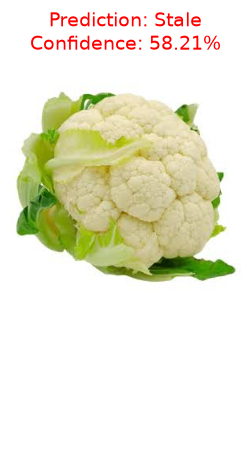

🎯 Result: Predicted vegetable state is 'Stale' with 58.21% confidence score parameters.


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# === CONFIGURATION ===
# Provide the path to any vegetable image on your Mac that you want to test
TEST_IMAGE_PATH = "/Users/mevinimunaweera/Downloads/test2.jpg"  # <-- Change this to test different files

# Path to your saved model file
MODEL_PATH = "./kmeans_saved_models/MobileNetV2_best_model.keras"

# Reverse class mapping dictionary based on your directory data configuration
class_mapping = {
    0: "Fresh",
    1: "Rotten",
    2: "Slightly_Aged",
    3: "Spoiled",
    4: "Stale",
}

# === 1. LOAD THE TRAINED MODEL ===
if not os.path.exists(MODEL_PATH):
    print(
        f"❌ Error: Model file not found at {MODEL_PATH}. Checking VGG16 alternative..."
    )
    MODEL_PATH = "./kmeans_saved_models/VGG16_best_model.keras"

print(f"🔄 Loading saved trained weights from: {MODEL_PATH}")
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Model successfully loaded and ready for inference!")

# === 2. LOAD AND PREPROCESS TEST IMAGE ===
if os.path.exists(TEST_IMAGE_PATH):
    # Read the image using OpenCV
    img_bgr = cv2.imread(TEST_IMAGE_PATH)

    if img_bgr is None:
        print(f"❌ Error: Could not read image matrix at {TEST_IMAGE_PATH}")
    else:
        # Convert BGR to RGB for correct matplotlib plotting colors
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Resize image to match the network training specification input shape (128x128)
        img_resized = cv2.resize(img_rgb, (128, 128))

        # Normalize pixel values down to [0.0, 1.0] scaling bounds
        img_normalized = img_resized / 255.0

        # Expand batch dimension shape array from (128, 128, 3) to (1, 128, 128, 3)
        input_tensor = np.expand_dims(img_normalized, axis=0)

        # === 3. EXECUTE INFERENCE PREDICTION ===
        predictions = model.predict(input_tensor)
        predicted_class_idx = np.argmax(predictions[0])
        confidence_score = predictions[0][predicted_class_idx] * 100

        # Fetch label text string name
        predicted_label = class_mapping.get(
            predicted_class_idx, "Unknown Quality Grade"
        )

        # === 4. VISUALIZE PREDICTION OUTPUT ===
        plt.figure(figsize=(5, 5))
        plt.imshow(img_rgb)
        plt.title(
            f"Prediction: {predicted_label}\nConfidence: {confidence_score:.2f}%",
            fontsize=14,
            color="green" if "Fresh" in predicted_label else "red",
        )
        plt.axis("off")
        plt.show()

        print(
            f"🎯 Result: Predicted vegetable state is '{predicted_label}' with {confidence_score:.2f}% confidence score parameters."
        )
else:
    print(
        f"⚠️ File path '{TEST_IMAGE_PATH}' does not exist. Please check your spelling layout strings."
    )


In [24]:
#test their models

🔄 Loading saved trained weights from: /Users/mevinimunaweera/Downloads/model_outputs/kmeans_saved_models/MobileNetV2_best_model.keras
✅ Model successfully loaded and ready for inference!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 866ms/step


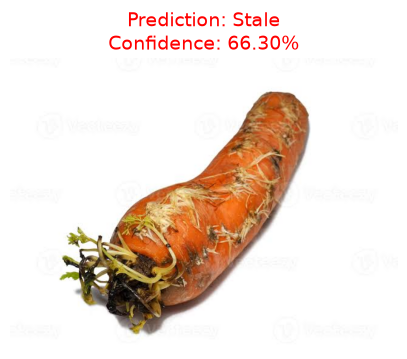

🎯 Result: Predicted vegetable state is 'Stale' with 66.30% confidence score parameters.


In [27]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# === CONFIGURATION ===
# Provide the path to any vegetable image on your Mac that you want to test
TEST_IMAGE_PATH = "/Users/mevinimunaweera/Downloads/images (1).jpeg"  # <-- Change this to test different files

# Path to your saved model file
MODEL_PATH = "/Users/mevinimunaweera/Downloads/model_outputs/kmeans_saved_models/MobileNetV2_best_model.keras"

# Reverse class mapping dictionary based on your directory data configuration
class_mapping = {
    0: "Fresh",
    1: "Rotten",
    2: "Slightly_Aged",
    3: "Spoiled",
    4: "Stale",
}

# === 1. LOAD THE TRAINED MODEL ===
if not os.path.exists(MODEL_PATH):
    print(
        f"❌ Error: Model file not found at {MODEL_PATH}. Checking VGG16 alternative..."
    )
    MODEL_PATH = "./kmeans_saved_models/VGG16_best_model.keras"

print(f"🔄 Loading saved trained weights from: {MODEL_PATH}")
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Model successfully loaded and ready for inference!")

# === 2. LOAD AND PREPROCESS TEST IMAGE ===
if os.path.exists(TEST_IMAGE_PATH):
    # Read the image using OpenCV
    img_bgr = cv2.imread(TEST_IMAGE_PATH)

    if img_bgr is None:
        print(f"❌ Error: Could not read image matrix at {TEST_IMAGE_PATH}")
    else:
        # Convert BGR to RGB for correct matplotlib plotting colors
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Resize image to match the network training specification input shape (128x128)
        img_resized = cv2.resize(img_rgb, (128, 128))

        # Normalize pixel values down to [0.0, 1.0] scaling bounds
        img_normalized = img_resized / 255.0

        # Expand batch dimension shape array from (128, 128, 3) to (1, 128, 128, 3)
        input_tensor = np.expand_dims(img_normalized, axis=0)

        # === 3. EXECUTE INFERENCE PREDICTION ===
        predictions = model.predict(input_tensor)
        predicted_class_idx = np.argmax(predictions[0])
        confidence_score = predictions[0][predicted_class_idx] * 100

        # Fetch label text string name
        predicted_label = class_mapping.get(
            predicted_class_idx, "Unknown Quality Grade"
        )

        # === 4. VISUALIZE PREDICTION OUTPUT ===
        plt.figure(figsize=(5, 5))
        plt.imshow(img_rgb)
        plt.title(
            f"Prediction: {predicted_label}\nConfidence: {confidence_score:.2f}%",
            fontsize=14,
            color="green" if "Fresh" in predicted_label else "red",
        )
        plt.axis("off")
        plt.show()

        print(
            f"🎯 Result: Predicted vegetable state is '{predicted_label}' with {confidence_score:.2f}% confidence score parameters."
        )
else:
    print(
        f"⚠️ File path '{TEST_IMAGE_PATH}' does not exist. Please check your spelling layout strings."
    )


In [30]:
#tested with all models to find the best model

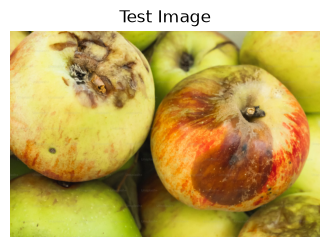

🔄 Loading and evaluating AlexNet...
🔄 Loading and evaluating AlexNet...
🔄 Loading and evaluating DenseNet121...
🔄 Loading and evaluating DenseNet121...
🔄 Loading and evaluating InceptionV3...
🔄 Loading and evaluating InceptionV3...
🔄 Loading and evaluating MobileNetV2...
🔄 Loading and evaluating MobileNetV2...
🔄 Loading and evaluating ResNet50...
🔄 Loading and evaluating ResNet50...
🔄 Loading and evaluating VGG16...
🔄 Loading and evaluating VGG16...
🔄 Loading and evaluating VGG19...
🔄 Loading and evaluating VGG19...
🔄 Loading and evaluating Xception...
🔄 Loading and evaluating Xception...

📋 === MULTI-MODEL COMPARISON MATRIX ===
 Model Name Predicted Quality Grade Confidence Score
    AlexNet                 Spoiled           76.07%
    AlexNet                 Spoiled           76.07%
DenseNet121                 Spoiled           53.51%
DenseNet121                 Spoiled           53.51%
InceptionV3                 Spoiled           51.50%
InceptionV3                 Spoiled          

In [29]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

# === CONFIGURATION ===
MODEL_FOLDER = (
    "/Users/mevinimunaweera/Downloads/model_outputs/kmeans_saved_models"
)
TEST_IMAGE_PATH = "/Users/mevinimunaweera/Downloads/test2.jpg"

if not os.path.exists(MODEL_FOLDER):
    raise FileNotFoundError(f"Folder path not found: {MODEL_FOLDER}")

# Automatically grab files ending with best_model.keras or model.keras
all_files = os.listdir(MODEL_FOLDER)
model_files = [f for f in all_files if f.endswith((".keras", ".h5"))]

class_mapping = {
    0: "Fresh",
    1: "Slightly_Aged",
    2: "Stale",
    3: "Spoiled",
    4: "Rotten",
}

# === IMAGE PREPROCESSING ===
if not os.path.exists(TEST_IMAGE_PATH):
    raise FileNotFoundError(f"Image not found at {TEST_IMAGE_PATH}")

img_bgr = cv2.imread(TEST_IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (128, 128))
img_normalized = img_resized / 255.0
input_tensor = np.expand_dims(img_normalized, axis=0)

# Display test image once
plt.figure(figsize=(4, 4))
plt.imshow(img_rgb)
plt.title("Test Image")
plt.axis("off")
plt.show()

# === INFERENCE LOOP ===
results = []

for file_name in sorted(model_files):
    model_name = (
        file_name.replace("_best_model.keras", "")
        .replace("_model.keras", "")
        .replace(".keras", "")
    )
    model_path = os.path.join(MODEL_FOLDER, file_name)

    print(f"🔄 Loading and evaluating {model_name}...")
    try:
        model = tf.keras.models.load_model(model_path, compile=False)

        # Run inference evaluation
        predictions = model.predict(input_tensor, verbose=0)

        # FIX 1: Safely unpack nested array values or dict formats returned by multi-output models
        if isinstance(predictions, list):
            predictions = predictions[0]
        elif isinstance(predictions, dict):
            # Fallback if model yields named tensor dictionary tracks
            key = list(predictions.keys())[0]
            predictions = predictions[key]

        # Flatten down to a strict 1D array to guarantee standard indexing succeeds
        predictions = np.array(predictions).flatten()

        # FIX 2: Calculate index position metrics safely
        predicted_class_idx = int(np.argmax(predictions))
        confidence_score = float(predictions[predicted_class_idx]) * 100
        predicted_label = class_mapping.get(predicted_class_idx, "Unknown")

        results.append(
            {
                "Model Name": model_name,
                "Predicted Quality Grade": predicted_label,
                "Confidence Score": f"{confidence_score:.2f}%",
            }
        )
    except Exception as e:
        print(f"⚠️ Could not evaluate model {model_name}: {e}")

# === DISPLAY COMPARISON EVALUATION ===
if results:
    df_comparison = pd.DataFrame(results)
    print("\n📋 === MULTI-MODEL COMPARISON MATRIX ===")
    print(df_comparison.to_string(index=False))
else:
    print("\n❌ No models were evaluated successfully. Check array formats.")


In [31]:
#only using best model


🔄 Loading fully trained VGG16 model...
✅ VGG16 model is online and ready!


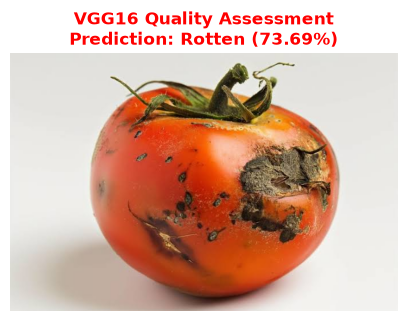

🎯 Result: State is 'Rotten' with 73.69% confidence.


In [35]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# ==========================================
# 🔄 QUICK TEST CONFIGURATION
# ==========================================
# Change this path string to test different images on your Mac
TEST_IMAGE_PATH = "/Users/mevinimunaweera/Downloads/images (2).jpeg"

# Hardcoded to use your best-performing VGG16 model weights file
MODEL_PATH = "/Users/mevinimunaweera/Downloads/model_outputs/kmeans_saved_models/VGG16_best_model.keras"

# Reverse class mapping dictionary matching your dataset configuration
class_mapping = {
    0: "Fresh",
    1: "Slightly_Aged",
    2: "Stale",
    3: "Spoiled",
    4: "Rotten",
}

# ==========================================
# 1. LOAD THE MODEL
# ==========================================
if not os.path.exists(MODEL_PATH):
    # Fallback to standard check if early stopping check wasn't flagged
    MODEL_PATH = "/Users/mevinimunaweera/Downloads/model_outputs/kmeans_saved_models/VGG16_model.keras"

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"❌ Could not find VGG16 model weights file at: {MODEL_PATH}"
    )

print("🔄 Loading fully trained VGG16 model...")
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("✅ VGG16 model is online and ready!")

# ==========================================
# 2. RUN INFERENCE ON NEW IMAGE
# ==========================================
if not os.path.exists(TEST_IMAGE_PATH):
    print(f"⚠️ Test image file path '{TEST_IMAGE_PATH}' does not exist.")
else:
    # Read and process the image matrix matching VGG shape requirements (128x128)
    img_bgr = cv2.imread(TEST_IMAGE_PATH)

    if img_bgr is None:
        print(f"❌ Error: Could not read image at {TEST_IMAGE_PATH}")
    else:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (128, 128))
        img_normalized = img_resized / 255.0
        input_tensor = np.expand_dims(img_normalized, axis=0)

        # Execute prediction and safely flatten multi-dimensional array bounds
        predictions = model.predict(input_tensor, verbose=0)
        predictions = np.array(predictions).flatten()

        predicted_class_idx = int(np.argmax(predictions))
        confidence_score = float(predictions[predicted_class_idx]) * 100
        predicted_label = class_mapping.get(predicted_class_idx, "Unknown")

        # Set semantic title colors dynamically
        title_color = "green" if predicted_label == "Fresh" else "red"

        # Display results graph window
        plt.figure(figsize=(5, 5))
        plt.imshow(img_rgb)
        plt.title(
            f"VGG16 Quality Assessment\nPrediction: {predicted_label} ({confidence_score:.2f}%)",
            fontsize=12,
            color=title_color,
            weight="bold",
        )
        plt.axis("off")
        plt.show()

        print(
            f"🎯 Result: State is '{predicted_label}' with {confidence_score:.2f}% confidence."
        )
